In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm

plt.rcParams["figure.figsize"] = (13, 6)

In [2]:
tsla = pd.read_csv("../data/processed/TSLA_cleaned.csv", index_col=0, parse_dates=True)
close = tsla["Close"].dropna()
print(f"Full history: {len(close)} rows, {close.index.min().date()} -> {close.index.max().date()}")

Full history: 2998 rows, 2015-01-02 -> 2026-06-30


In [3]:
final_model = pm.auto_arima(
    close,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    d=None,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    trace=True,
)
print("\nFinal model order (p, d, q):", final_model.order)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=20321.120, Time=0.27 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=20320.541, Time=0.31 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=20320.550, Time=0.34 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=20320.142, Time=0.19 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=20322.457, Time=1.49 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 2.647 seconds

Final model order (p, d, q): (0, 1, 0)


In [4]:
FORECAST_DAYS = 252  # ~12 months of trading days

future_forecast, future_ci = final_model.predict(n_periods=FORECAST_DAYS, return_conf_int=True)
future_dates = pd.bdate_range(start=close.index[-1] + pd.Timedelta(days=1), periods=FORECAST_DAYS)

future_forecast = pd.Series(future_forecast, index=future_dates)
future_lower = pd.Series(future_ci[:, 0], index=future_dates)
future_upper = pd.Series(future_ci[:, 1], index=future_dates)

print(f"Forecast period: {future_dates[0].date()} -> {future_dates[-1].date()}")
print(future_forecast.head())
print(future_forecast.tail())

Forecast period: 2026-07-01 -> 2027-06-17
2026-07-01    411.839996
2026-07-02    411.839996
2026-07-03    411.839996
2026-07-06    411.839996
2026-07-07    411.839996
Freq: B, dtype: float64
2027-06-11    411.839996
2027-06-14    411.839996
2027-06-15    411.839996
2027-06-16    411.839996
2027-06-17    411.839996
Freq: B, dtype: float64


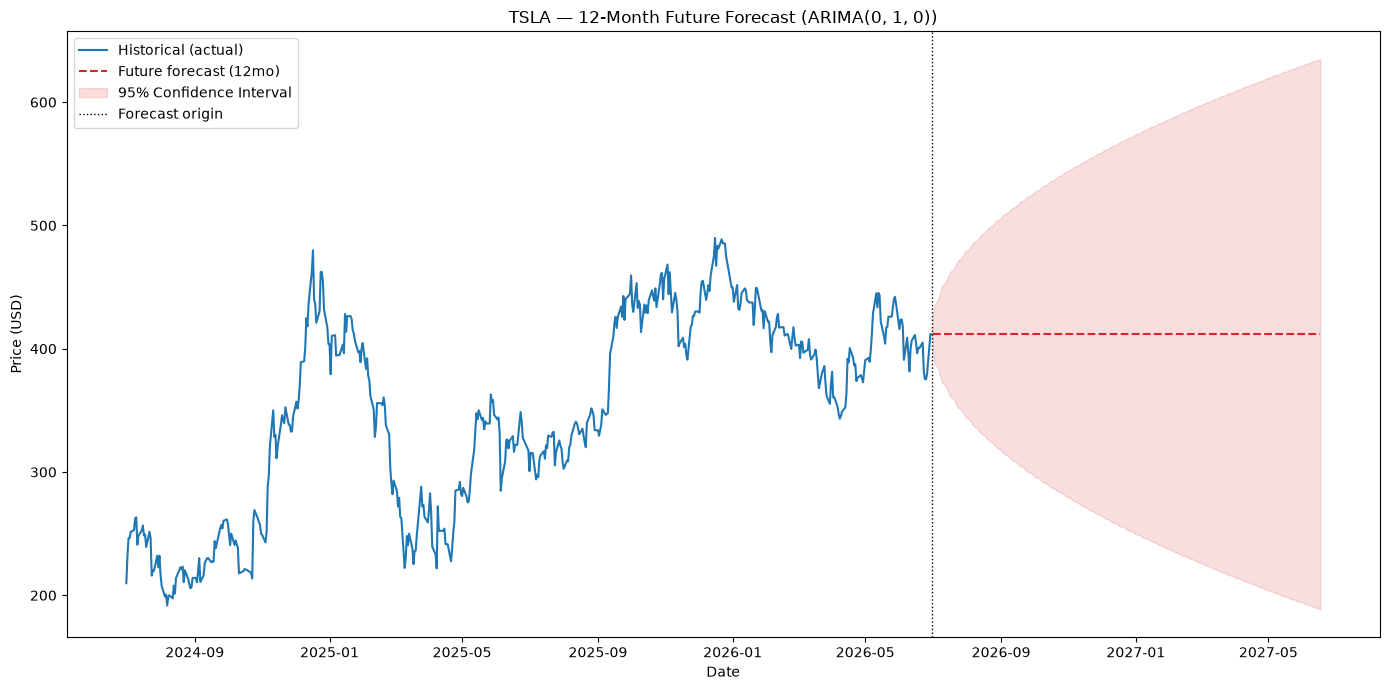

In [5]:
fig, ax = plt.subplots(figsize=(14, 7))

history_window = close[close.index >= "2024-07-01"]
ax.plot(history_window.index, history_window, label="Historical (actual)", color="tab:blue")

ax.plot(future_forecast.index, future_forecast, label="Future forecast (12mo)",
        color="tab:red", linestyle="--")
ax.fill_between(future_forecast.index, future_lower, future_upper,
                 color="tab:red", alpha=0.15, label="95% Confidence Interval")

ax.axvline(close.index[-1], color="black", linestyle=":", linewidth=1, label="Forecast origin")
ax.set_title(f"TSLA — 12-Month Future Forecast (ARIMA{final_model.order})")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig_task3_future_forecast.png", dpi=120)
plt.show()

Last known price (2026-06-30): $411.84
Forecast at +1 month:  $411.84  (CI width: $131.95)
Forecast at +6 months: $411.84  (CI width: $315.77)
Forecast at +12 months: $411.84  (CI width: $446.57)


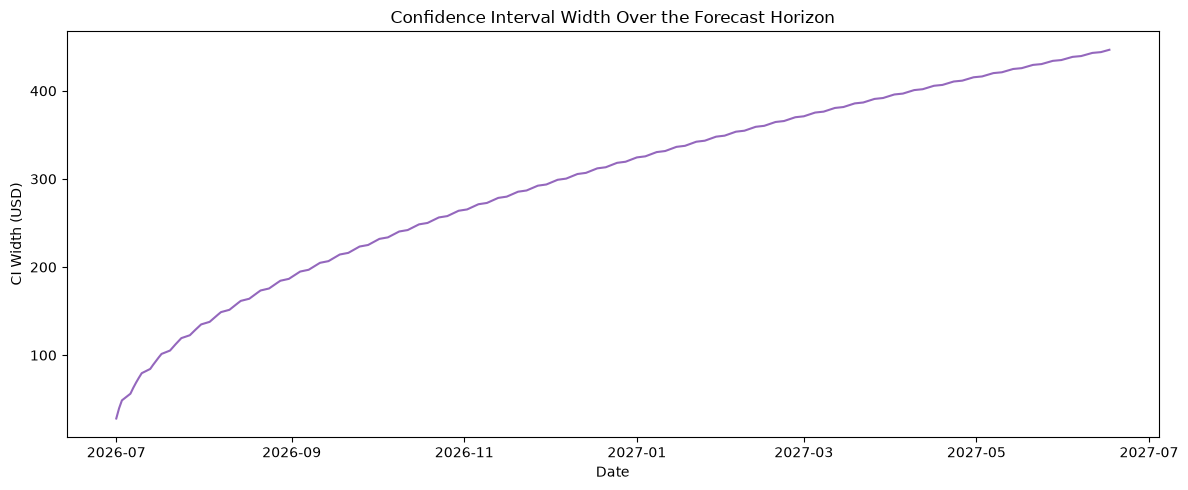

In [6]:
ci_width = future_upper - future_lower

print(f"Last known price ({close.index[-1].date()}): ${close.iloc[-1]:.2f}")
print(f"Forecast at +1 month:  ${future_forecast.iloc[21]:.2f}  (CI width: ${ci_width.iloc[21]:.2f})")
print(f"Forecast at +6 months: ${future_forecast.iloc[125]:.2f}  (CI width: ${ci_width.iloc[125]:.2f})")
print(f"Forecast at +12 months: ${future_forecast.iloc[-1]:.2f}  (CI width: ${ci_width.iloc[-1]:.2f})")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(future_forecast.index, ci_width, color="tab:purple")
ax.set_title("Confidence Interval Width Over the Forecast Horizon")
ax.set_xlabel("Date")
ax.set_ylabel("CI Width (USD)")
plt.tight_layout()
plt.savefig("../data/processed/fig_task3_ci_widening.png", dpi=120)
plt.show()